# Euler Milstein comparison
## Plots and Tables

Some Initialization

In [37]:
%load_ext autoreload
%autoreload 2

import lib
import numpy as np
import matplotlib.pyplot as plt
#import pandas as pd
import os
import time




# Model parameters
S0, K = 100, 100     # Initial stock price and strike
r = 0.05             # Risk-free rate
sigma = 0.3          # Volatility
gamma = 0.7          # CEV parameter
T = 1.0              # Time to maturity
M = 252              # Number of time steps (daily)

# Create simulation instance
sim = lib.MonteCarloSimulation(S0, K, r, sigma, gamma, T, M)

# Set simulation parameters
N = 2**17            # Number of paths (power of 2 for QMC)
batches = 32          # Number of batches/scrambles

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [11]:
rng = np.random.default_rng(1234)  # fixed seed for reproducibility
N_ref=2**17 
M_ref=10000
sim_ref = lib.MonteCarloSimulation(S0, K, r, sigma, gamma, T, M_ref)

Z_ref = rng.standard_normal(size=(N_ref, M_ref))
payoffs_ref_e = sim_ref.price_asian_option_from_Z_raw(Z_ref, euler=True)   # array of length N (discounted payoffs)
payoffs_ref_m = sim_ref.price_asian_option_from_Z_raw(Z_ref, euler=False)  # array of length N (discounted payoffs)
mean_ref_e = float(payoffs_ref_e.mean())
mean_ref_m = float(payoffs_ref_m.mean())

print(f"Reference mean (Euler-Maruyama, M={M_ref}, N={N_ref}): {mean_ref_e:.6f}")
print(f"Reference mean (Milstein, M={M_ref}, N={N_ref}): {mean_ref_m:.6f}")

Reference mean (Euler-Maruyama, M=10000, N=131072): 17.822323
Reference mean (Milstein, M=10000, N=131072): 17.822743


## Option price vs Step size

Paired bias estimate (M=256): -4.882238e-02 ± 6.505e-03 (95% CI)


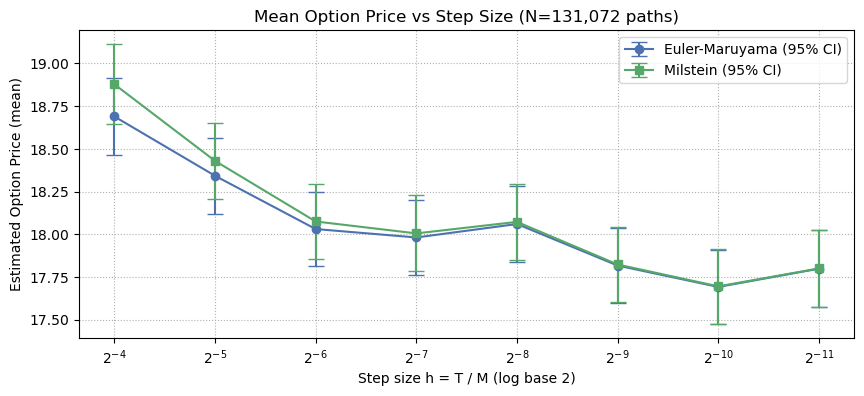

In [18]:
N = 2**17   
sim = lib.MonteCarloSimulation(S0, K, r, sigma, gamma, T, M)
# Mean option price vs step size h: Euler-Maruyama vs Milstein
# Uses existing `sim`, `N`, `np`, `plt`. Restores sim.M after the experiment.

orig_M = sim.M
M_values = [16, 32, 64, 128, 256, 512, 1024, 2048]   # different time-step resolutions
#M_values = range(16, 1024, 50)  # M from 16 to 2048 in steps of 16
means_euler = []
ses_euler = []
means_milstein = []
ses_milstein = []
times_euler = []
times_milstein = []

rng = np.random.default_rng(1234)  # fixed seed for reproducibility

for M_current in M_values:
    sim.M = M_current
    # draw standard normals: shape (N, M)
    rng = np.random.default_rng(1234)  # fixed seed for reproducibility
    Z = rng.standard_normal(size=(N, sim.M))

    # Euler-Maruyama using the library's payoff-from-Z helper (per-path payoffs -> mean & SE)
    Starteuler = time.perf_counter()
    payoffs_e = sim.price_asian_option_from_Z_raw(Z, euler=True)   # array of length N (discounted payoffs)
    mean_e = float(payoffs_e.mean())
    se_e = float(payoffs_e.std(ddof=1) / (N**0.5))
    Endeuler = time.perf_counter()

    means_euler.append(mean_e)
    ses_euler.append(se_e)
    times_euler.append(Endeuler - Starteuler)

    # Milstein using the same Z (CRN between schemes)
    Startmilstein = time.perf_counter()
    payoffs_m = sim.price_asian_option_from_Z_raw(Z, euler=False)
    mean_m = float(payoffs_m.mean())
    se_m = float(payoffs_m.std(ddof=1) / (N**0.5))
    Endmilstein = time.perf_counter()
    
    means_milstein.append(mean_m)
    ses_milstein.append(se_m)
    times_milstein.append(Endmilstein - Startmilstein)

# restore original M
sim.M = orig_M

h_values = [sim.T / M for M in M_values]

# Compute 95% CI half-widths (normal approximation).
# If you prefer a t-quantile for small sample sizes or batch-based variance estimates, replace 1.96 with t.ppf(1 - alpha/2, df).
alpha=0.05
from scipy.stats import t
df = N - 1
z95 = t.ppf(1 - alpha/2, df)#1.96
ci_half_euler = [z95 * s for s in ses_euler]
ci_half_milstein = [z95 * s for s in ses_milstein]

plt.figure(figsize=(10,4))
plt.errorbar(h_values, means_euler, yerr=ci_half_euler, fmt='o-', label='Euler-Maruyama (95% CI)', capsize=6, color='#4C72B0')
plt.errorbar(h_values, means_milstein, yerr=ci_half_milstein, fmt='s-', label='Milstein (95% CI)', capsize=6, color='#55A868')
plt.xscale('log', base=2)
plt.gca().invert_xaxis()  # smaller h (finer grid) to the right
plt.xlabel('Step size h = T / M (log base 2)')
plt.ylabel('Estimated Option Price (mean)')
plt.title(f'Mean Option Price vs Step Size (N={N:,} paths)')
plt.legend()
plt.grid(True, which='both', ls=':')
os.makedirs('Graphs', exist_ok=True)
plt.savefig(os.path.join('Graphs', 'Euler_vs_Milstein.png'), bbox_inches='tight')
plt.show()

In [38]:
# Paired (CRN) bias estimation using a fine-resolution reference (batched to limit memory)
# We use M_ref divisible by all coarse M_values (8192 works for the M_values list above).
M_ref = 8192*2
assert all(M_ref % M == 0 for M in M_values), 'Choose M_ref divisible by all M_values'
k_values = [M_ref // M for M in M_values]
# Total paired paths and batching to limit memory use
N_pair_total = 2**14  # total paired paths (adjust if you want higher precision)
batch_size = 2048
n_batches = int(np.ceil(N_pair_total / batch_size))
print(f'Paired bias estimation: M_ref={M_ref}, total paths={N_pair_total}, batch_size={batch_size}, batches={n_batches}')
paired_bias_euler = []
paired_se_euler = []
paired_bias_milstein = []
paired_se_milstein = []
# Use a different RNG stream per M to avoid accidental correlations across configurations
for M_current in M_values:
    k = M_ref // M_current
    sim_ref = lib.MonteCarloSimulation(S0, K, r, sigma, gamma, T, M_ref)
    sim_coarse_e = lib.MonteCarloSimulation(S0, K, r, sigma, gamma, T, M_current)
    sim_coarse_m = lib.MonteCarloSimulation(S0, K, r, sigma, gamma, T, M_current)
    S1 = 0.0
    S2 = 0.0
    T1 = 0.0
    T2 = 0.0
    Nacc = 0
    rng = np.random.default_rng(12345 + M_current)
    for b in range(n_batches):
        this_bs = min(batch_size, N_pair_total - Nacc)
        if this_bs <= 0:
            break
        # draw fine-resolution standard normals and compute payoffs at fine and coarsened grids
        Z_fine = rng.standard_normal(size=(this_bs, M_ref))
        payoff_f_e = sim_ref.price_asian_option_from_Z_raw(Z_fine, euler=True)
        payoff_f_m = sim_ref.price_asian_option_from_Z_raw(Z_fine, euler=False)
        # coarsen by summing blocks of size k and scaling
        Z_coarse = Z_fine.reshape(this_bs, M_current, k).sum(axis=2) / np.sqrt(k)
        payoff_c_e = sim_coarse_e.price_asian_option_from_Z_raw(Z_coarse, euler=True)
        payoff_c_m = sim_coarse_m.price_asian_option_from_Z_raw(Z_coarse, euler=False)
        diff_e = payoff_f_e - payoff_c_e
        diff_m = payoff_f_m - payoff_c_m
        S1 += diff_e.sum()
        S2 += (diff_e**2).sum()
        T1 += diff_m.sum()
        T2 += (diff_m**2).sum()
        Nacc += this_bs
    Nn = Nacc
    mean_e = S1 / Nn
    var_e = (S2 - Nn * mean_e**2) / (Nn - 1) if Nn > 1 else 0.0
    se_e = np.sqrt(var_e / Nn) if Nn > 0 else 0.0
    paired_bias_euler.append(float(mean_e))
    paired_se_euler.append(float(se_e))
    mean_m = T1 / Nn
    var_m = (T2 - Nn * mean_m**2) / (Nn - 1) if Nn > 1 else 0.0
    se_m = np.sqrt(var_m / Nn) if Nn > 0 else 0.0
    paired_bias_milstein.append(float(mean_m))
    paired_se_milstein.append(float(se_m))
    print(f'M={M_current}: paired bias Euler={mean_e:.6e} (SE={se_e:.2e}), Milstein={mean_m:.6e} (SE={se_m:.2e})')
print('Finished paired bias estimation.')

Paired bias estimation: M_ref=16384, total paths=16384, batch_size=2048, batches=8
M=16: paired bias Euler=-1.780076e-01 (SE=1.81e-03), Milstein=-1.787432e-01 (SE=1.80e-03)
M=16: paired bias Euler=-1.780076e-01 (SE=1.81e-03), Milstein=-1.787432e-01 (SE=1.80e-03)
M=32: paired bias Euler=-8.757811e-02 (SE=8.97e-04), Milstein=-8.786131e-02 (SE=8.85e-04)
M=32: paired bias Euler=-8.757811e-02 (SE=8.97e-04), Milstein=-8.786131e-02 (SE=8.85e-04)
M=64: paired bias Euler=-4.402724e-02 (SE=4.50e-04), Milstein=-4.424087e-02 (SE=4.44e-04)
M=64: paired bias Euler=-4.402724e-02 (SE=4.50e-04), Milstein=-4.424087e-02 (SE=4.44e-04)
M=128: paired bias Euler=-2.202748e-02 (SE=2.27e-04), Milstein=-2.209947e-02 (SE=2.22e-04)
M=128: paired bias Euler=-2.202748e-02 (SE=2.27e-04), Milstein=-2.209947e-02 (SE=2.22e-04)
M=256: paired bias Euler=-1.097534e-02 (SE=1.13e-04), Milstein=-1.100506e-02 (SE=1.09e-04)
M=256: paired bias Euler=-1.097534e-02 (SE=1.13e-04), Milstein=-1.100506e-02 (SE=1.09e-04)
M=512: paired

In [52]:
paired_se_euler

[0.0018135302422951298,
 0.0008967479475234105,
 0.0004497390959534388,
 0.00022739972745196041,
 0.00011322523846010907,
 5.794046407356852e-05,
 3.021587487066948e-05,
 1.574385436742382e-05]

In [53]:
paired_se_milstein

[0.0017955782119428614,
 0.0008850741432466142,
 0.000444057308052387,
 0.0002221505664694466,
 0.0001091957813043904,
 5.3833830806575084e-05,
 2.6593288673222324e-05,
 1.2550091298993663e-05]

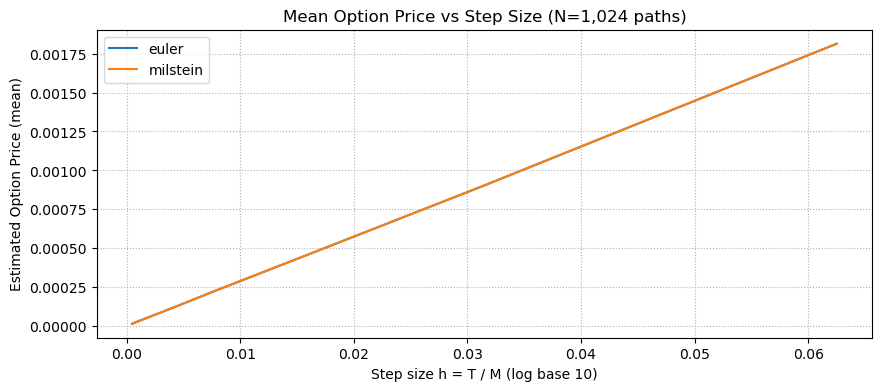

In [55]:
plt.figure(figsize=(10,4))
#plt.errorbar(h_values, means_euler, yerr=ci_half_euler, fmt='o-', label='Euler-Maruyama (95% CI)', capsize=6, color='#4C72B0')
#plt.errorbar(h_values, means_milstein, yerr=ci_half_milstein, fmt='s-', label='Milstein (95% CI)', capsize=6, color='#55A868')
plt.plot(h_values, paired_se_euler, label='euler')
plt.plot(h_values,paired_se_euler,label='milstein')
#plt.xscale('log', base=10)
#plt.gca().invert_xaxis()  # smaller h (finer grid) to the right
plt.xlabel('Step size h = T / M (log base 10)')
plt.ylabel('Estimated Option Price (mean)')
plt.title(f'Mean Option Price vs Step Size (N={N:,} paths)')
plt.legend()
plt.grid(True, which='both', ls=':')
os.makedirs('Graphs', exist_ok=True)
plt.savefig(os.path.join('Graphs', 'Euler_vs_Milstein.png'), bbox_inches='tight')
plt.show()

In [40]:
import pandas as pd

# Build summary table
# Build summary table (use paired-bias estimates computed above)
df = pd.DataFrame({
    'M': M_values,
    'h': h_values,
    'Mean_Euler': means_euler,
    'Bias_Euler': paired_bias_euler,
    'SE_Bias_Euler': paired_se_euler,
    'SE_Euler': ses_euler,
    'CI_Euler_L': [m - 1.96*s for m, s in zip(means_euler, ses_euler)],
    'CI_Euler_U': [m + 1.96*s for m, s in zip(means_euler, ses_euler)],
    'Time_Euler': times_euler,
    'Mean_Milstein': means_milstein,
    'Bias_Milstein': paired_bias_milstein,
    'SE_Bias_Milstein': paired_se_milstein,
    'SE_Milstein': ses_milstein,
    'CI_Mil_L': [m - 1.96*s for m, s in zip(means_milstein, ses_milstein)],
    'CI_Mil_U': [m + 1.96*s for m, s in zip(means_milstein, ses_milstein)],
    'CI_Width_Euler': [2*1.96*s for s in ses_euler],
    'CI_Width_Milstein': [2*1.96*s for s in ses_milstein],
    'Time_Milstein': times_milstein
})

# Helpful diagnostics
df['Mean_Diff (Milstein - Euler)'] = df['Mean_Milstein'] - df['Mean_Euler']
df['SE_Ratio (Mil/Eu)'] = df['SE_Milstein'] / df['SE_Euler']
df['Time_diff (Mil - Eu)'] = df['Time_Milstein'] - df['Time_Euler']

# Pretty print
pd.options.display.float_format = '{:.6f}'.format
df_display = df[['M', 'Mean_Euler', 'Bias_Euler', 'SE_Euler', 'CI_Width_Euler',
                 'Mean_Milstein', 'Bias_Milstein', 'SE_Milstein', 'CI_Width_Milstein',
                 'SE_Ratio (Mil/Eu)', 'Time_Euler', 'Time_Milstein','Time_diff (Mil - Eu)']]

# make column names tighter in an extra snippet
# 1) remove any literal "\_" escapes
df.columns = [c.replace('\\_', '_') for c in df.columns]

# 2) map to shorter names
short_map = {
    'Mean_Euler': '$Mean_{Euler}$',
    'Bias_Euler': '$Bias_{Euler}$',
    'SE_Bias_Euler': '$SE_{Bias, Euler}$',
    'SE_Euler': '$SE_{Euler}$',
    'CI_Width_Euler': '$CIw_{Euler}$',
    'Time_Euler': '$Time_{Euler}$',
    'Mean_Milstein': '$Mean_{Milstein}$',
    'Bias_Milstein': '$Bias_{Milstein}$',
    'SE_Bias_Milstein': '$SE_{Bias, Milstein}$',
    'SE_Milstein': '$SE_{Milstein}$',
    'CI_Width_Milstein': '$CIw_{Milstein}$',
    'Time_Milstein': '$Time_{Milstein}$',
    'SE_Ratio (Mil/Eu)': '$SE_{ratio}$',
    'Time_diff (Mil - Eu)': '$Time_{diff}$',
    }
df.rename(columns=short_map, inplace=True)

# 3) refresh the display frame to use the new short names
df_display = df[['M', '$Mean_{Euler}$', '$Bias_{Euler}$', '$SE_{Bias, Euler}$', '$SE_{Euler}$','$Time_{Euler}$', '$Mean_{Milstein}$', '$Bias_{Milstein}$', '$SE_{Bias, Milstein}$', '$SE_{Milstein}$', '$Time_{Milstein}$','$SE_{ratio}$']]
display(df_display)


,M,$Mean_{Euler}$,$Bias_{Euler}$,"$SE_{Bias, Euler}$",$SE_{Euler}$,$Time_{Euler}$,$Mean_{Milstein}$,$Bias_{Milstein}$,"$SE_{Bias, Milstein}$",$SE_{Milstein}$,$Time_{Milstein}$,$SE_{ratio}$
0,16,18.689682,-0.178008,0.001814,0.116123,0.154525,18.878255,-0.178743,0.001796,0.119971,0.113148,1.033142
1,32,18.342555,-0.087578,0.000897,0.112896,0.255327,18.429759,-0.087861,0.000885,0.114476,0.225927,1.013989
2,64,18.030709,-0.044027,0.000450,0.110885,0.483493,18.075042,-0.044241,0.000444,0.111704,0.430952,1.007387
3,128,17.981460,-0.022027,0.000227,0.113003,0.965817,18.005309,-0.022099,0.000222,0.113526,0.967314,1.004634
4,256,18.060225,-0.010975,0.000113,0.112759,2.161147,18.072740,-0.011005,0.000109,0.113017,2.176583,1.002290
5,512,17.817012,-0.005317,0.000058,0.112366,5.261816,17.823226,-0.005308,0.000054,0.112481,5.144307,1.001026
6,1024,17.691817,-0.002597,0.000030,0.111072,11.717687,17.695208,-0.002612,0.000027,0.111133,11.508167,1.000552
7,2048,17.798656,-0.001232,0.000016,0.115018,25.722214,17.800148,-0.001229,0.000013,0.115062,24.058424,1.000389


In [25]:
# simple export (what you had)
# simple export (what you had)
os.makedirs('Tables', exist_ok=True)
out_path = os.path.join('Tables', 'Euler_Milstein_Comparison.tex')
df_display.to_latex(out_path, index=False, float_format="%.4f")
print(f"Saved LaTeX table to {out_path}")

Saved LaTeX table to Tables/Euler_Milstein_Comparison.tex


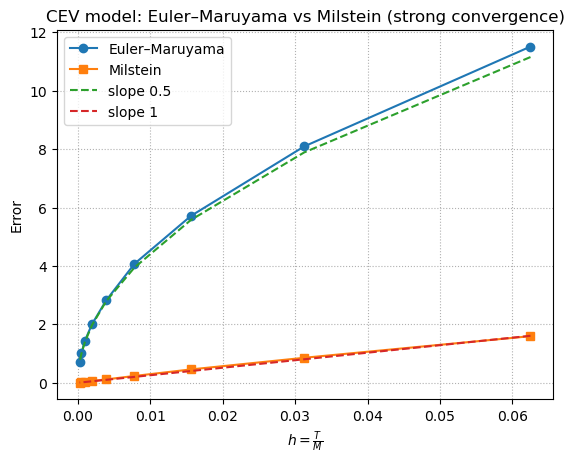

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- Model parameters ----------
mu = 0.05
sigma = 0.3
beta = 1.2        # genuine CEV (not constant vol)
S0 = 1.0
T = 1.0

M = 10000          # number of paths
N_ref = 2**13     # very fine grid for reference solution


# ---------- CEV drift and diffusion ----------
def drift(S):
    return mu * S

def diffusion(S):
    # enforce non-negativity to avoid issues with S**beta
    return sigma * np.maximum(S, 0.0)**beta

def diffusion_prime(S):
    return sigma * beta * np.maximum(S, 0.0)**(beta - 1.0)


# ---------- Milstein step ----------
def milstein_step(S, dt, dW):
    b = diffusion(S)
    b_prime = diffusion_prime(S)
    return S + drift(S) * dt + b * dW + 0.5 * b * b_prime * (dW**2 - dt)


# ---------- Euler–Maruyama step ----------
def euler_step(S, dt, dW):
    return S + drift(S) * dt + diffusion(S) * dW


# ---------- Reference solution on fine grid (Milstein with very small dt) ----------
dt_ref = T / N_ref
sqrt_dt_ref = np.sqrt(dt_ref)

# Brownian increments for all paths and all small steps
dW_ref = sqrt_dt_ref * np.random.randn(M, N_ref)

S_ref = np.full(M, S0)
for n in range(N_ref):
    S_ref = milstein_step(S_ref, dt_ref, dW_ref[:, n])

S_ref_T = S_ref.copy()  # S_T "truth"


# ---------- Compare for coarser step sizes ----------
N_list = [2**k for k in range(4, 13)]  # 16, 32, ..., 4096
dt_list = []
err_euler = []
err_milstein = []

for N in N_list:
    if N_ref % N != 0:
        # we require N to divide N_ref so we can aggregate increments
        continue

    m = N_ref // N   # how many fine steps per coarse step
    dt = T / N
    dt_list.append(dt)

    # aggregate fine increments into coarse ones
    dW_coarse = dW_ref.reshape(M, N, m).sum(axis=2)

    # simulate Euler–Maruyama
    S_euler = np.full(M, S0)
    for n in range(N):
        S_euler = euler_step(S_euler, dt, dW_coarse[:, n])

    # simulate Milstein
    S_milstein = np.full(M, S0)
    for n in range(N):
        S_milstein = milstein_step(S_milstein, dt, dW_coarse[:, n])

    # strong L1 error vs reference at T
    err_euler.append(np.mean(np.abs(S_euler - S_ref_T)))
    err_milstein.append(np.mean(np.abs(S_milstein - S_ref_T)))


# ---------- Plot log–log error vs dt ----------
dt_arr = np.array(dt_list)
err_euler = np.array(err_euler)
err_milstein = np.array(err_milstein)

plt.figure()
plt.plot(dt_arr, err_euler, 'o-', label='Euler–Maruyama')
plt.plot(dt_arr, err_milstein, 's-', label='Milstein')

# Optional: reference slopes (dt^0.5 and dt^1) for visual guidance
plt.plot(dt_arr, dt_arr**0.5 * err_euler[-1] / (dt_arr[-1]**0.5), '--', label='slope 0.5')
plt.plot(dt_arr, dt_arr**1.0 * err_milstein[-1] / (dt_arr[-1]**1.0), '--', label='slope 1')

plt.xlabel(r'$h=\frac{T}{M}$')
plt.ylabel('Error')
plt.title('CEV model: Euler–Maruyama vs Milstein (strong convergence)')
plt.legend()
plt.grid(True, which='both', ls=':')
plt.show()


In [68]:
err_euler

array([11.50981149,  8.09060748,  5.71358964,  4.07060652,  2.81701976,
        2.00327109,  1.43638156,  1.00197992,  0.69697806])

In [69]:
err_milstein

array([1.59510961, 0.85524167, 0.45693865, 0.23251405, 0.11543754,
       0.05978175, 0.02977095, 0.0144571 , 0.00628242])